In [1]:
!pip install pm4py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import pm4py

In [25]:
df = pd.read_csv("incident_management.csv", sep = ";")
df.head(2)

,Case ID,Variant,Priority,Reporter,Timestamp,Event,Issue Type,Resolver,Report Channel,Short Description,Customer Satisfaction
0,INC0001,Variant 4,Medium,Alice,17/11/2023 11:17,Ticket created,Performance Issue,NaN,Website,Application crash,3
1,INC0001,Variant 4,Medium,Alice,17/11/2023 13:30,Ticket assigned to level 1 support,Performance Issue,Sam,Website,Application crash,3


In [26]:
df.dtypes

,0
Case ID,object
Variant,object
Priority,object
Reporter,object
Timestamp,object
Event,object
Issue Type,object
Resolver,object
Report Channel,object
Short Description,object


In [27]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

/tmp/ipykernel_17854/3991263233.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Timestamp"] = pd.to_datetime(df["Timestamp"])


In [28]:
df.head(1)

,Case ID,Variant,Priority,Reporter,Timestamp,Event,Issue Type,Resolver,Report Channel,Short Description,Customer Satisfaction
0,INC0001,Variant 4,Medium,Alice,2023-11-17 11:17:00,Ticket created,Performance Issue,NaN,Website,Application crash,3


In [29]:
df.dtypes

,0
Case ID,object
Variant,object
Priority,object
Reporter,object
Timestamp,datetime64[ns]
Event,object
Issue Type,object
Resolver,object
Report Channel,object
Short Description,object


In [30]:
event_log = pm4py.format_dataframe(df, case_id = "Case ID", activity_key = "Event", timestamp_key = "Timestamp")

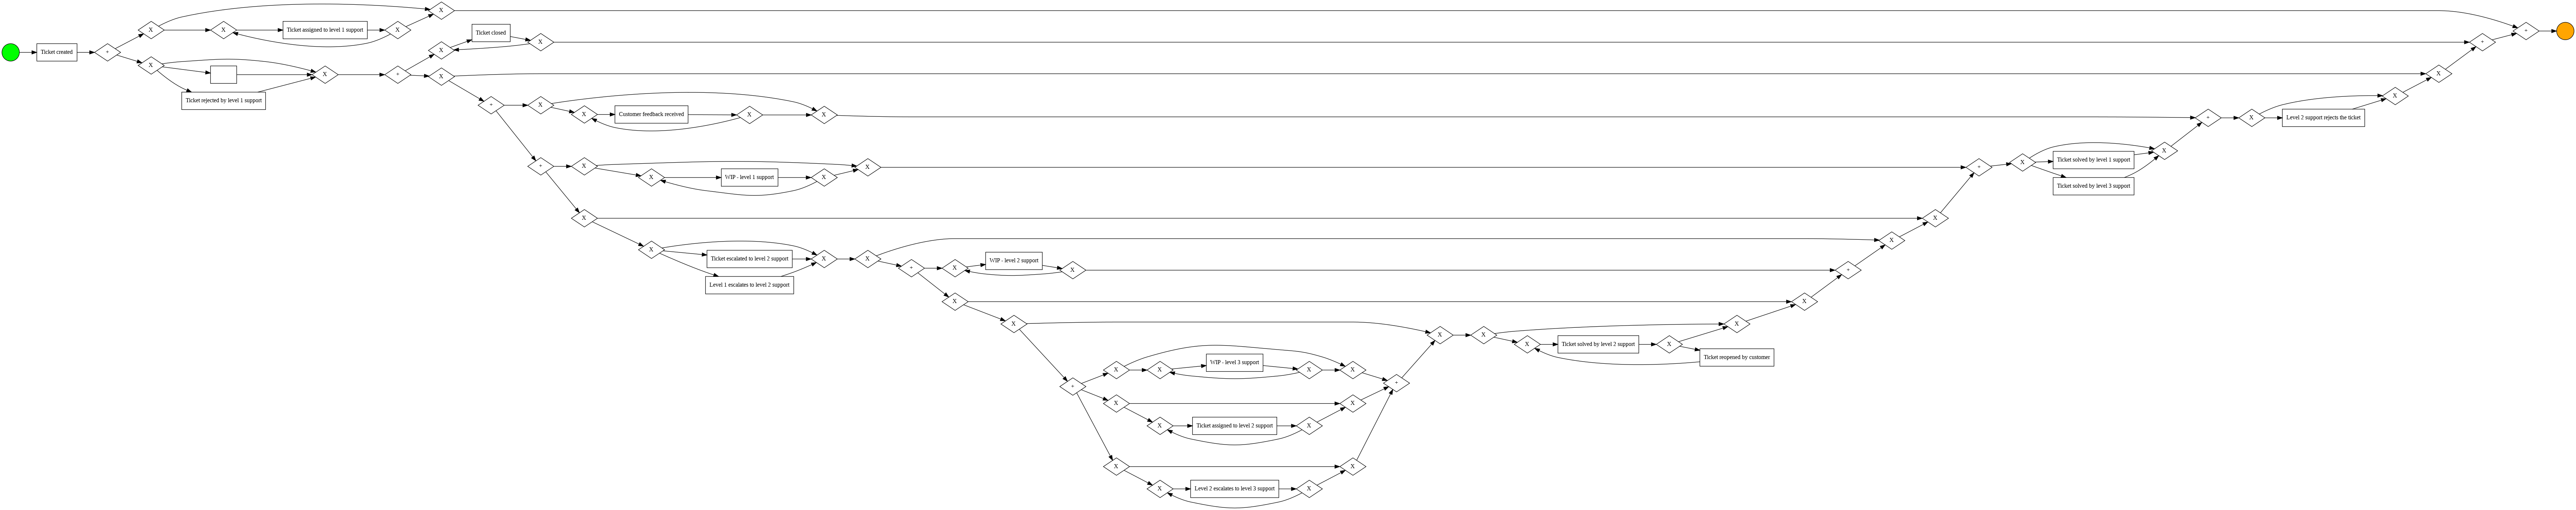

In [31]:
# Descubrimiento del modelo BPMN con Inductive Miner
bpmn_model = pm4py.discover_bpmn_inductive(event_log)
pm4py.view_bpmn(bpmn_model)

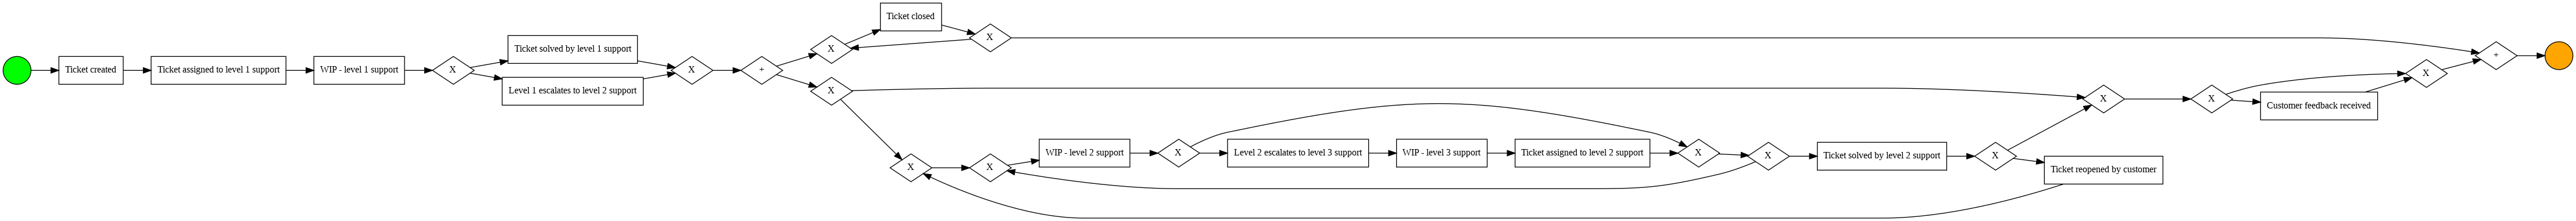

In [32]:
# mantener solo las 5 variantes más frecuentes
event_log_filtrado = pm4py.filter_variants_top_k(event_log, k=5)

bpmn_model_filtrado = pm4py.discover_bpmn_inductive(event_log_filtrado)
pm4py.view_bpmn(bpmn_model_filtrado)

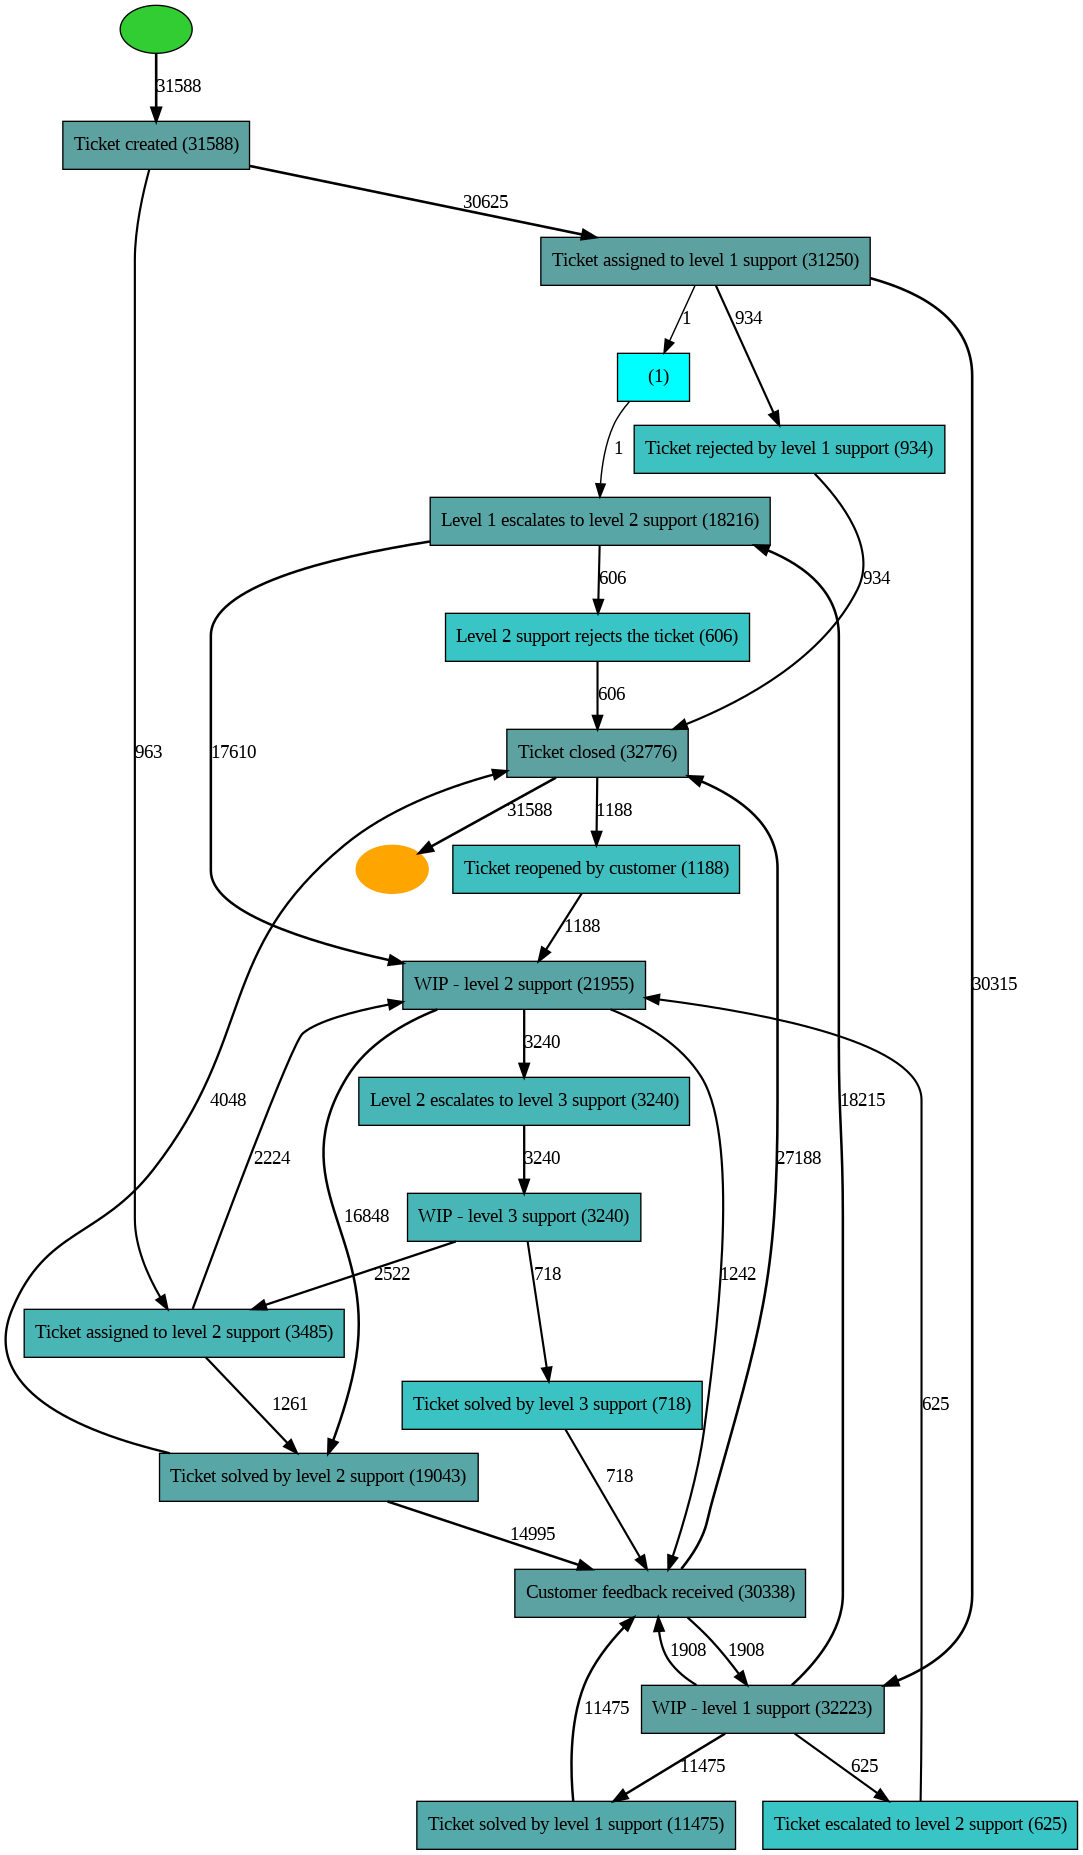

In [33]:
# Descubrimiento del modelo BPMN con Heuristic Miner para manejar concurrencias
heuristic_net = pm4py.discover_heuristics_net(event_log)
pm4py.view_heuristics_net(heuristic_net)

/usr/local/lib/python3.12/dist-packages/pm4py/algo/discovery/dfg/adapters/pandas/df_statistics.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[start_timestamp_key] = df[timestamp_key]


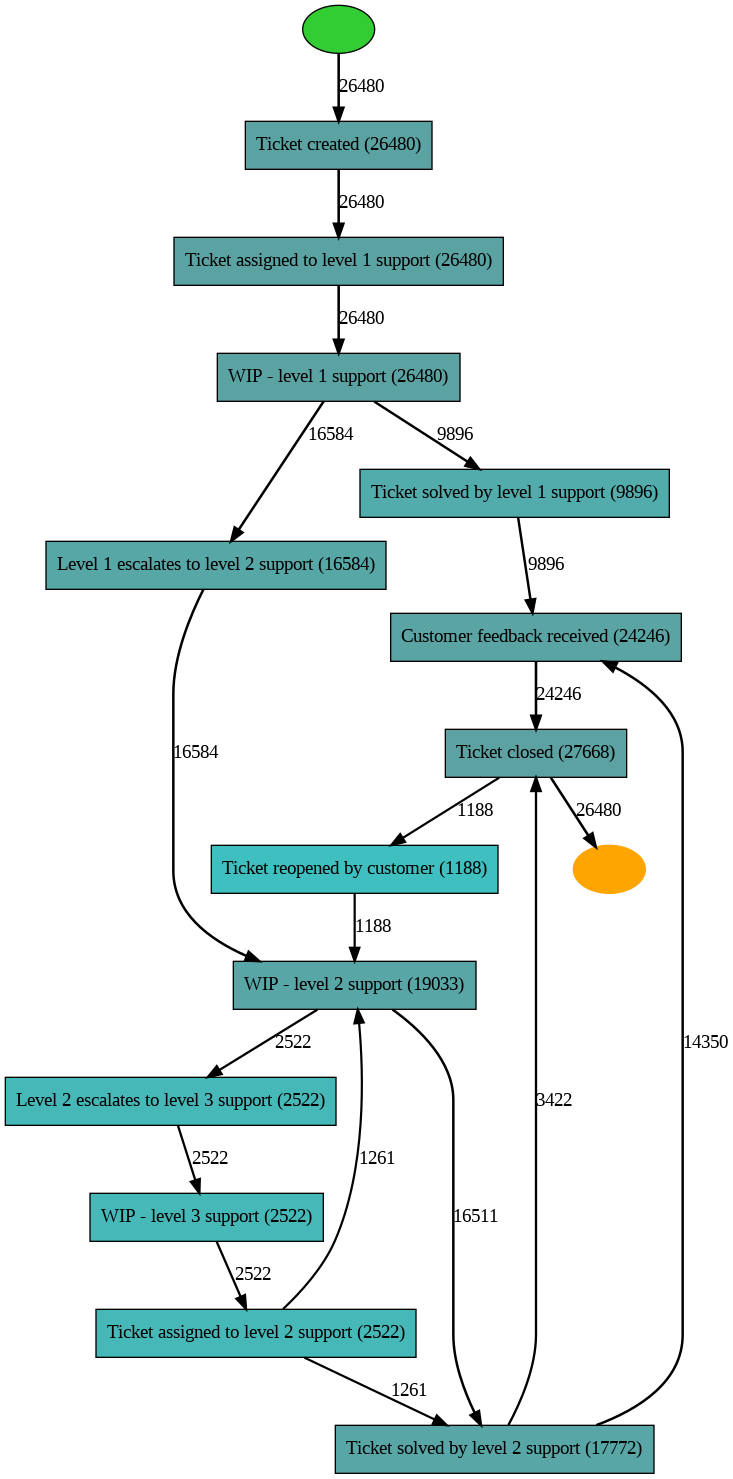

In [34]:
# event_log filtrado (5 varianes más frecuentes)
heuristic_net = pm4py.discover_heuristics_net(event_log_filtrado)
pm4py.view_heuristics_net(heuristic_net)

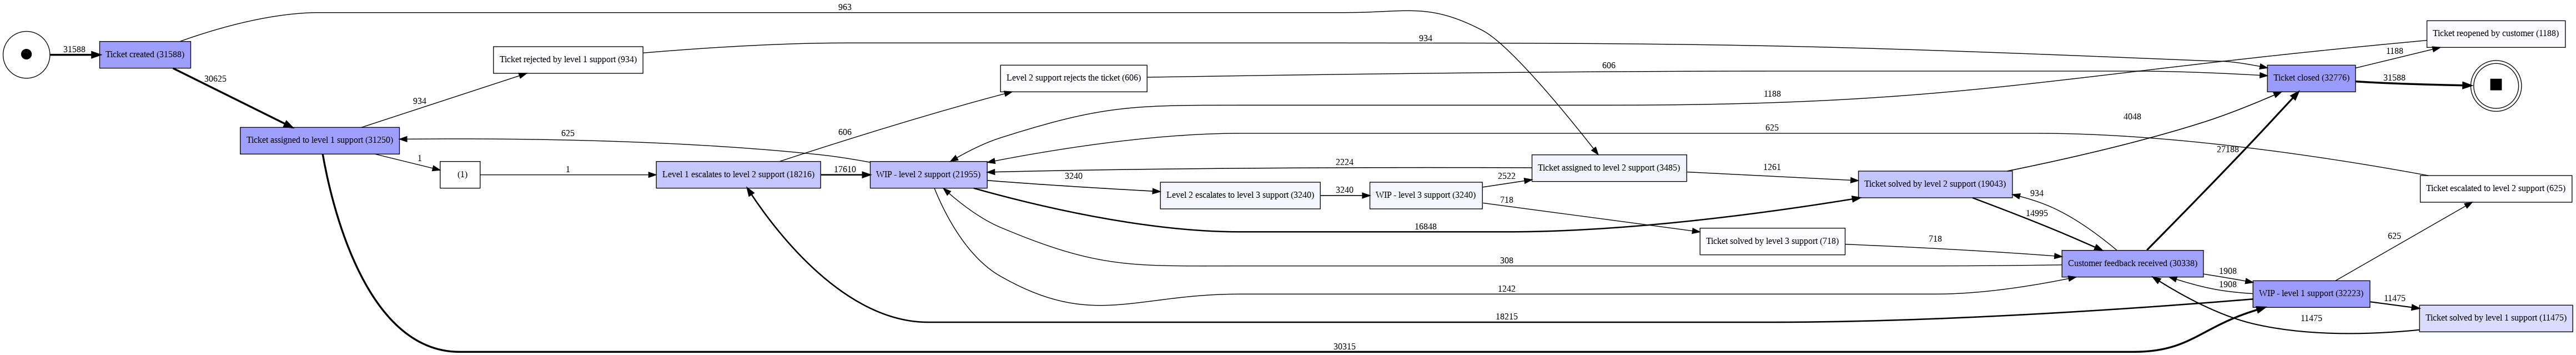

In [35]:
# Descubrimiento con Directly-Follows Graph (DFG) para obtener concurrencias explícitas
dfg, start_activities, end_activities = pm4py.discover_dfg(event_log)
pm4py.view_dfg(dfg, start_activities, end_activities)

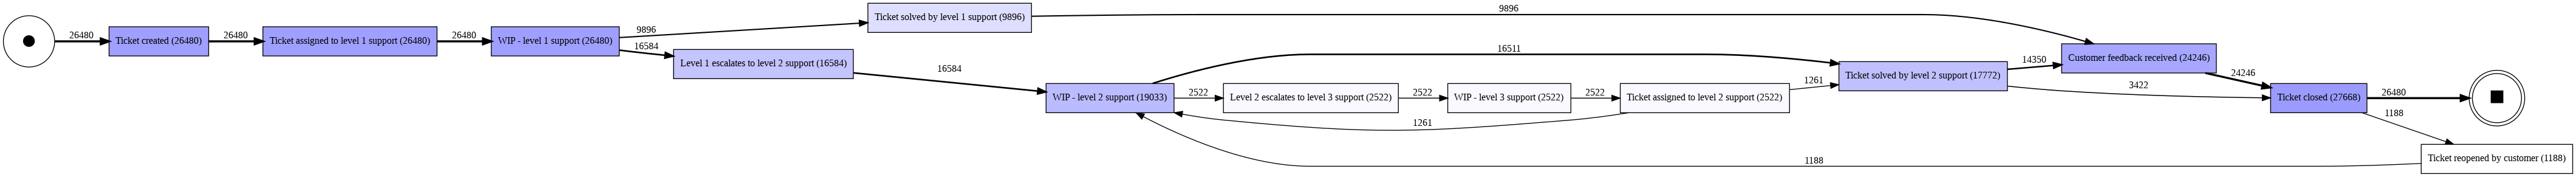

In [36]:
# Descubrimiento con Directly-Follows Graph (DFG): 5 variantes más frecuentes
dfg, start_activities, end_activities = pm4py.discover_dfg(event_log_filtrado)
pm4py.view_dfg(dfg, start_activities, end_activities)

In [37]:
net, initial_marking, final_marking = pm4py.convert_to_petri_net(bpmn_model)

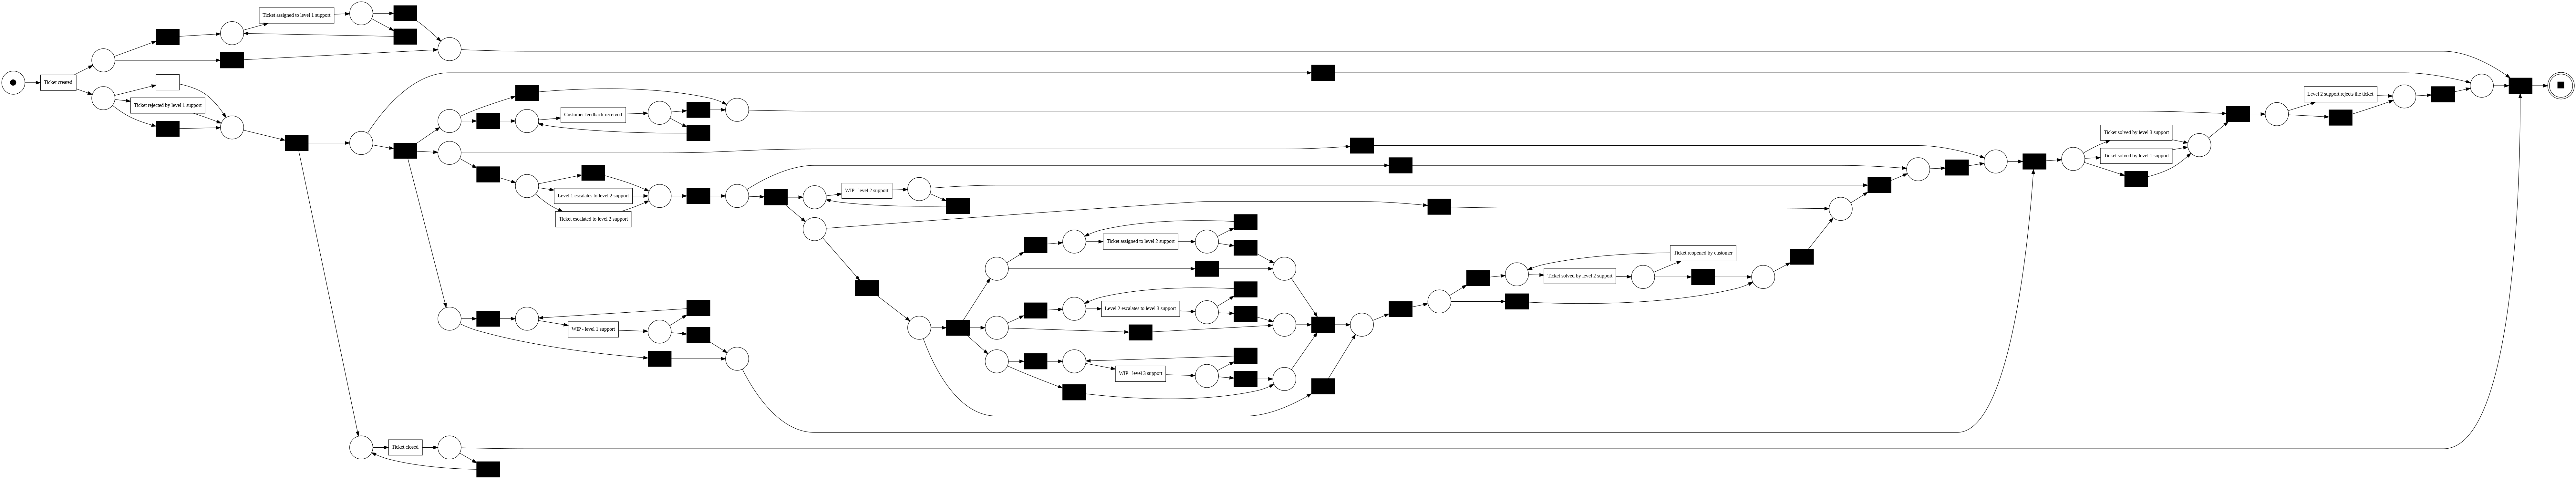

In [38]:
pm4py.view_petri_net(net, initial_marking, final_marking)

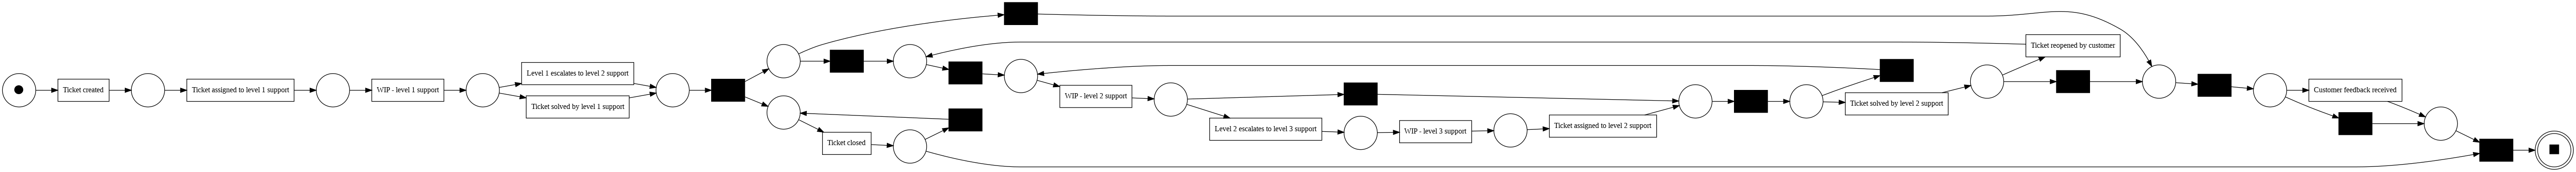

In [39]:
# Red de Petri variantes más frecuentes
net, initial_marking, final_marking = pm4py.convert_to_petri_net(bpmn_model_filtrado)
pm4py.view_petri_net(net, initial_marking, final_marking)